### Install SHAP 

In [1]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

### Load Dataset

In [3]:
df = pd.read_csv("Battery_dataset.csv")
df.head()

,battery_id,cycle,chI,chV,chT,disI,disV,disT,BCt,SOH,RUL
0,B5,1,1.440147,4.254682,23.988733,1.894407,3.273523,32.980834,1.986196,99.309790,219
1,B5,2,1.416595,4.159825,25.665347,1.829949,4.038741,32.257920,1.986240,99.311985,218
2,B5,3,1.420272,4.276323,25.407910,1.942105,3.214433,35.134801,1.984252,99.212608,217
3,B5,4,1.337680,4.236697,27.069757,2.073577,3.134529,32.082988,1.969236,98.461812,216
4,B5,5,1.263946,4.142791,26.478353,2.049885,3.729341,32.483154,1.974862,98.743106,215


### Create SAME Target (as Phase 2)

In [4]:
y = df["RUL"]

### Feature Engineering (same as Phase 2)

In [5]:
df["power_ch"] = df["chV"] * df["chI"]
df["power_dis"] = df["disV"] * df["disI"]

df["temp_diff"] = df["chT"] - df["disT"]
df["current_diff"] = df["chI"] - df["disI"]
df["voltage_diff"] = df["chV"] - df["disV"]

### Select Features (NO leakage)

In [6]:
X = df[
    [
        "cycle",
        "chI", "chV", "chT",
        "disI", "disV", "disT",
        "power_ch", "power_dis",
        "temp_diff", "current_diff", "voltage_diff"
    ]
]

### Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train XGBoost Model

In [8]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Create SHAP Explainer

In [9]:
explainer = shap.Explainer(model)

### Calculate SHAP Values

In [11]:
# Use sample (faster)
X_sample = X_test.sample(100, random_state=42)

shap_values = explainer(X_sample)

### SHAP Summary Plot

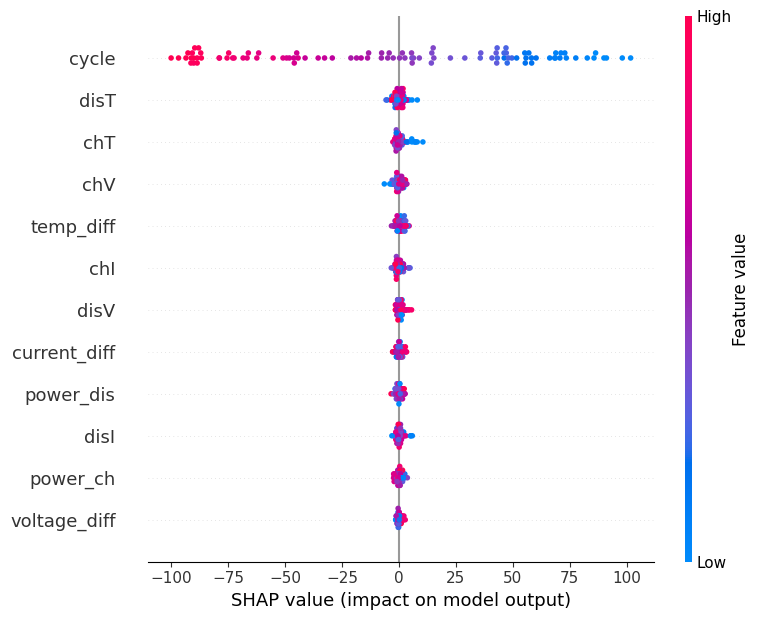

In [12]:
shap.summary_plot(shap_values, X_sample)

### SHAP Bar Plot

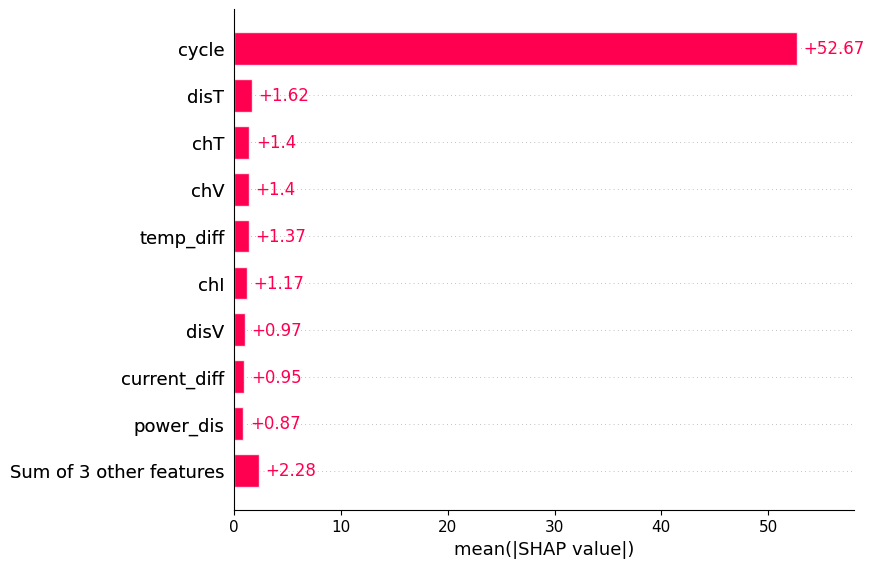

In [13]:
shap.plots.bar(shap_values)

### SHAP Waterfall Plot

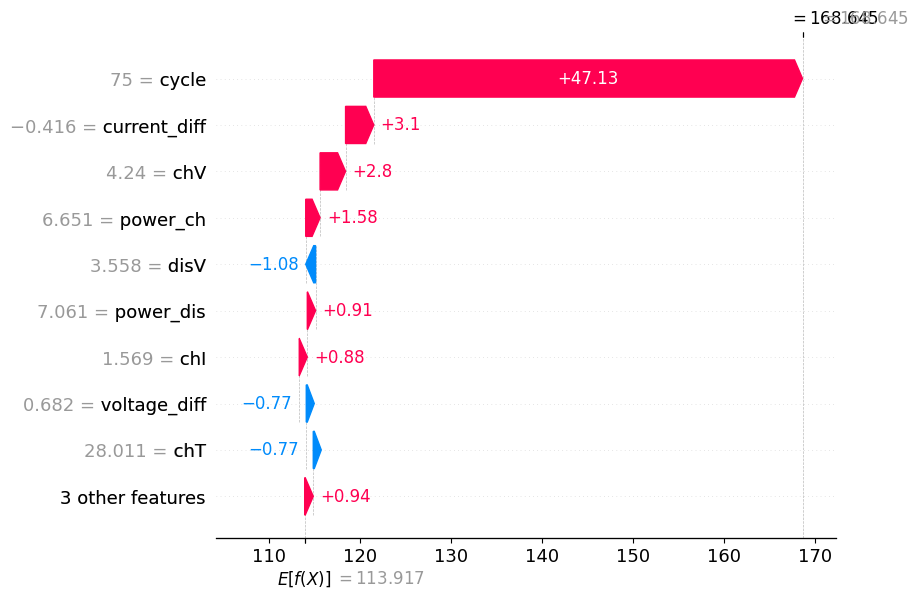

In [14]:
shap.plots.waterfall(shap_values[0])